# COMIND Subtyping Demo
This notebook contains an experiment where synthetic longitudinal patient data is generated from a known model and is recovered using COMIND


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import confusion_matrix, adjusted_rand_score

from COMIND_transformer.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from COMIND_transformer.synthetic_data_generator import generate_synthetic_data
from COMIND_transformer.visualization import * 
from COMIND_transformer.utils import *
from COMIND_transformer.subtyping_em_transformer import SubtypingEM
from COMIND_transformer.posthoc_burnin_subtype_initialization import initialize_subtypes_with_burnin

np.set_printoptions(precision=4)


In [2]:
# data params
n_biomarkers = 3
t_max = 7
t_span = np.linspace(0, t_max, 800)
noise_level = 0.1
n_patients = 100 # was 200
n_patient_obs = 3
n_subtypes = 3 #3,4,5
rng = np.random.RandomState(75)

# ground-truth global self-propagation kappa (one per biomarker)
# similar scale to f, random in [0.0, 0.1]
# true_kappa = rng.uniform(0.0, 3, size=n_biomarkers)


For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.


In [3]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

eigenvalues, eigenvectors = np.linalg.eig(K)

# print(f"eigenvalues: {eigenvalues}")
# print(f"eigenvectors: {eigenvectors}")

v = eigenvectors[:, 0]

if np.abs(np.min(v)) > np.abs(np.max(v)):
    v = -v

v_normalized = v / np.linalg.norm(v)
#print(v_normalized)
v_normalized = v_normalized + rng.uniform(-0.25, 0.25, size=n_biomarkers) # noise
np.clip(v_normalized, 0.0, np.inf)
print(f"kappa: {v_normalized}")

true_kappa = v_normalized 
v_normalized[1] = 0.0
np.fill_diagonal(K, v_normalized)

print(K)

kappa: [0.7256 0.3439 0.6498]
[[0.7256 1.     0.7805]
 [1.     0.     0.1159]
 [0.7805 0.1159 0.6498]]


SUBTYPE 0:
f: [0.  0.  0.3]
a = 4.676436127196727, b = 6.421955999238555


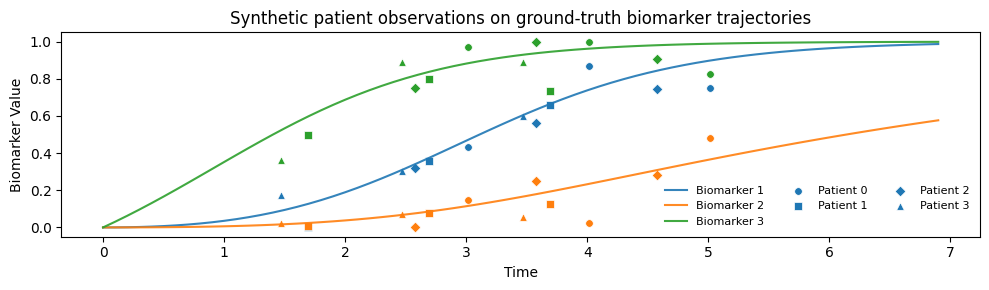

2.0825497783678255
SUBTYPE 1:
f: [0.3 0.  0. ]
a = 1.1927249100009507, b = 6.8096301386771785


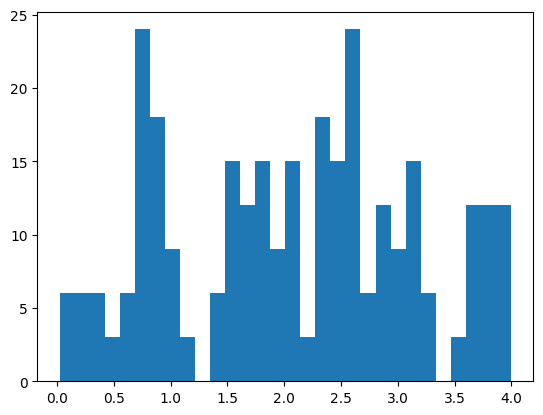

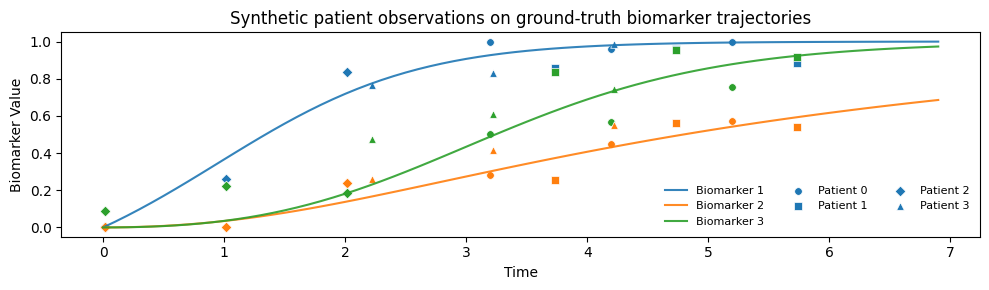

1.980709205848541
SUBTYPE 2:
f: [0.  0.3 0. ]
a = 3.0026725053615246, b = 4.680674259481151


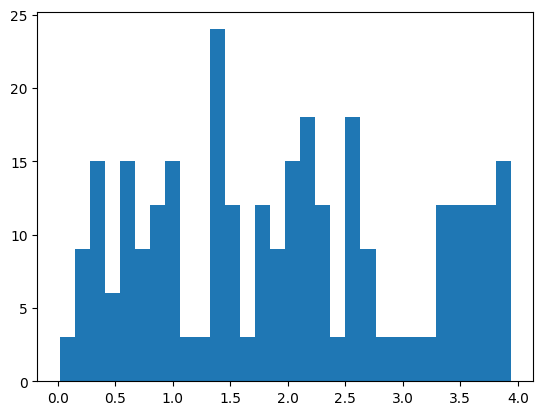

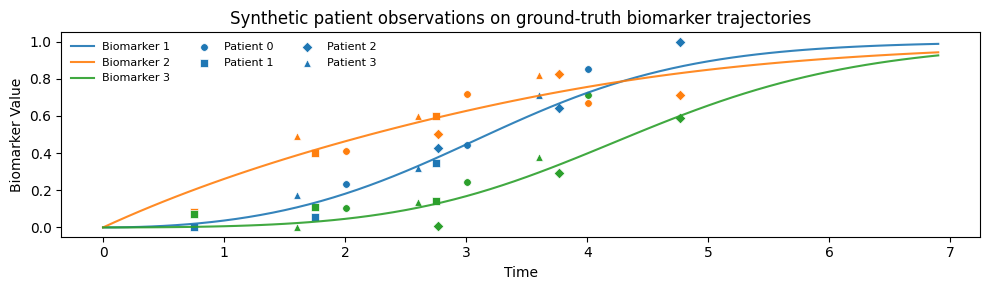

2.006035437041956


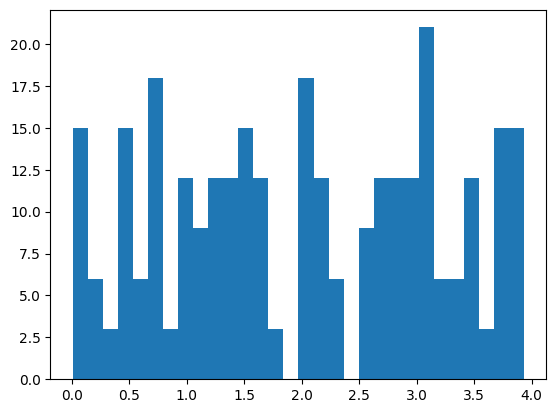

In [4]:
scalar_K_list = [0.2, 0.2, 0.2]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

f_list = [np.array([0.0, 0.0, 0.3]), np.array([0.3, 0.0, 0.0]), np.array([0.0, 0.3, 0.0])]

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    t, x_true, K, x0, f, scalar_K, kappa_true  = generate_logistic_model(
        n_biomarkers=n_biomarkers,
        scalar_K=scalar_K_list[subtype],
        t_max=t_max,
        K=K,
        f=f_list[subtype],
        kappa=true_kappa,
    )

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype + 2),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    plt.hist(beta_true, bins=30)
    print(np.mean(beta_true))
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    
X = np.asarray(X)
y = np.concatenate(y)


In [5]:
all_dt = np.concatenate([p["dt"] for p in X])
all_cog = np.concatenate([p["cog"] for p in X])
all_ids_array = np.concatenate([[p["id"]] * len(p["dt"]) for p in X])

initial_beta, pid_to_beta, result = fit_mixedlm_beta_from_clinical(
    ids=all_ids_array,
    dt=all_dt,
    cog=all_cog,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

unique_ids = np.unique([p["id"] for p in X])
beta_true_array = y
        
print(f"Initialized beta for {len(initial_beta)} patients")
print(f"Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"True beta range: [{np.min(beta_true_array):.2f}, {np.max(beta_true_array):.2f}]")


beta_init summary: count    300.000000
mean       3.042049
std        1.677473
min        0.000000
25%        1.745121
50%        2.600821
75%        4.085345
max        7.000000
dtype: float64
Initialized beta for 300 patients
Beta range: [0.00, 7.00]
True beta range: [0.01, 3.99]


## Grid Search with K-Fold Cross-Validation

We'll perform grid search over hyperparameters using K-fold cross-validation (not group k-fold).


In [6]:
# Initialize f for all models
f_init = initialize_f_eigen(K, n_subtypes=4, n_eigs=8, jitter=True, sparsity_mask=True, rng=np.random.RandomState(72))
if isinstance(f_init, list):
    f_init = f_init[0]

print(f_init)

# Add initial_beta to patient data
unique_ids = np.unique([p["id"] for p in X])
id_to_beta_idx = {pid: idx for idx, pid in enumerate(unique_ids)}
for p in X:
    p["initial_beta"] = initial_beta[id_to_beta_idx[p["id"]]]
    # SubjectEM also expects beta_pred (use initial_beta as starting point)
    p["beta_pred"] = float(initial_beta[id_to_beta_idx[p["id"]]])

# Add initialization fields required by SubjectEM (for burn-in initialization)
# These are used as starting points for the per-patient SubjectEM burn-in
s_init = np.ones(n_biomarkers)  # Default initialization for s
scalar_K_init = float(np.max([np.max(p["X_obs"]) for p in X]))  # Use max observed value

for p in X:
    p["f_init"] = f_init[0].copy()   # (3,) for SubjectEM  # Use the f_init from eigen initialization
    p["s_init"] = s_init.copy()
    p["scalar_K_init"] = scalar_K_init


[[0.7406 0.4637 0.    ]
 [0.6344 0.6321 0.    ]
 [0.     0.5158 0.7864]
 [0.8157 0.4777 0.    ]]


In [7]:
# Define parameter grid for grid search (n_subtypes fixed by BIC below)
param_grid = {
    "lambda_f": [1.0],
    "lambda_cog": [0.0],
    "lambda_scalar": [0.0],
    "lambda_jsd": [0],
    "lambda_kappa": [1.0],
    "epsilon": [1e-3],
    "jac_toggle": [True],
    "max_iter": [15],
    "t_max": [t_max],
    "step": [0.01],
    "K": [K],
    "verbose": [0],  # Set to 0 to reduce output during grid search
    "rng": [np.random.default_rng(75)],
    "assignments_jitter": [False],
    "jitter_iter": [0],
    "verbose": [1],
}

print(f"Parameter grid size: {np.prod([len(v) for v in param_grid.values()])} combinations")
print(f"K-fold CV will be performed for each combination")


Parameter grid size: 1 combinations
K-fold CV will be performed for each combination


$$SSE_b = \sum_{r} \big( X_{obs} - X_{pred} \big)^2$$

In [8]:
import time
import cProfile, pstats, io
from sklearn.model_selection import GridSearchCV, KFold

# ----- debug/runtime-friendly settings -----
candidate_n_subtypes = [3]
n_splits = 2
kf = KFold(n_splits=n_splits, shuffle=True, random_state=75)

bic_per_K = {}
best_model_per_K = {}
best_params_per_K = {}
profile_per_K = {}

for K_val in candidate_n_subtypes:
    print(f"\nGridSearchCV for n_subtypes={K_val}")

    base_estimator = SubtypingEM(
        K=K,
        initial_f=f_init[:K_val],
        n_subtypes=K_val,
        jac_toggle=True,
        max_iter=1000,      # lower temporarily if needed for profiling, e.g. 50-150
        t_max=t_max,
        step=0.01,
        epsilon=5e-2,
        lambda_f=0.545,
        lambda_cog=0.001,
        lambda_scalar=0.1,
        lambda_jsd=1.0,
        verbose=1,
        rng=np.random.default_rng(75),
    )

    grid = GridSearchCV(
        estimator=base_estimator,
        param_grid=param_grid,
        cv=kf,
        scoring=None,
        n_jobs=1,            # <- key workaround (avoid per-worker compile/runtime blowup)
        pre_dispatch=1,
        verbose=1,
        return_train_score=False,
    )

    pr = cProfile.Profile()
    t0 = time.perf_counter()
    pr.enable()
    grid.fit(X=X, y=None)
    pr.disable()
    elapsed = time.perf_counter() - t0

    best_est = grid.best_estimator_
    bic_val = best_est.bic(X)
    bic_per_K[K_val] = bic_val
    best_model_per_K[K_val] = best_est
    best_est.bic_ = bic_val
    best_params_per_K[K_val] = grid.best_params_

    print(f"  Best CV score: {grid.best_score_:.6f}, BIC: {bic_val:.4f}")
    print(f"  Elapsed: {elapsed/60:.2f} min")

    s = io.StringIO()
    pstats.Stats(pr, stream=s).sort_stats("cumtime").print_stats(40)
    profile_per_K[K_val] = s.getvalue()
    print("\nTop profiler entries:\n")
    print(profile_per_K[K_val][:4000])  # trim output length

best_n_subtypes = min(bic_per_K, key=bic_per_K.get)
best_model = best_model_per_K[best_n_subtypes]
print(f"\nBIC per K: {bic_per_K}")
print(f"Chosen n_subtypes: {best_n_subtypes} (lowest BIC)")


GridSearchCV for n_subtypes=3
Fitting 2 folds for each of 1 candidates, totalling 2 fits


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [01:19<00:00,  5.30s/it]

  Best CV score: -97.303152, BIC: 553.7995
  Elapsed: 3.33 min

Top profiler entries:

         125533613 function calls (125533064 primitive calls) in 199.833 seconds

   Ordered by: cumulative time
   List reduced from 756 to 40 due to restriction <40>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000  199.834  199.834 /home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/sklearn/base.py:1348(wrapper)
        1    0.000    0.000  199.833  199.833 /home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/sklearn/model_selection/_search.py:914(fit)
        3    0.035    0.012  192.559   64.186 /home/dsemchin/COMIND/COMIND_transformer/subtyping_em_transformer.py:111(fit)
      525    0.021    0.000  191.489    0.365 /home/dsemchin/miniconda3/envs/comind/lib/python3.10/site-packages/scipy/optimize/_minimize.py:53(minimize)
      525    0.109    0.000  191.352    0.364 /home/dsemchin/miniconda3/envs/comind/lib/python

In [9]:
# Best model and K were set in the previous cell (Option 1). Summary:
print(f"Best n_subtypes: {best_n_subtypes}")
print(f"Best params for chosen K: {best_params_per_K[best_n_subtypes]}")
print(f"BIC of best model: {best_model.bic_:.4f}")
if hasattr(best_model, 'lse_history') and len(best_model.lse_history) > 0:
    print(f"Final LSE: {best_model.lse_history[-1]:.6f}")

Best n_subtypes: 3
Best params for chosen K: {'K': array([[0.7256, 1.    , 0.7805],
       [1.    , 0.    , 0.1159],
       [0.7805, 0.1159, 0.6498]]), 'assignments_jitter': False, 'epsilon': 0.001, 'jac_toggle': True, 'jitter_iter': 0, 'lambda_cog': 0.0, 'lambda_f': 1.0, 'lambda_jsd': 0, 'lambda_kappa': 1.0, 'lambda_scalar': 0.0, 'max_iter': 15, 'rng': Generator(PCG64) at 0x7F5588E84120, 'step': 0.01, 't_max': 7, 'verbose': 1}
BIC of best model: 553.7995
Final LSE: 20.489170


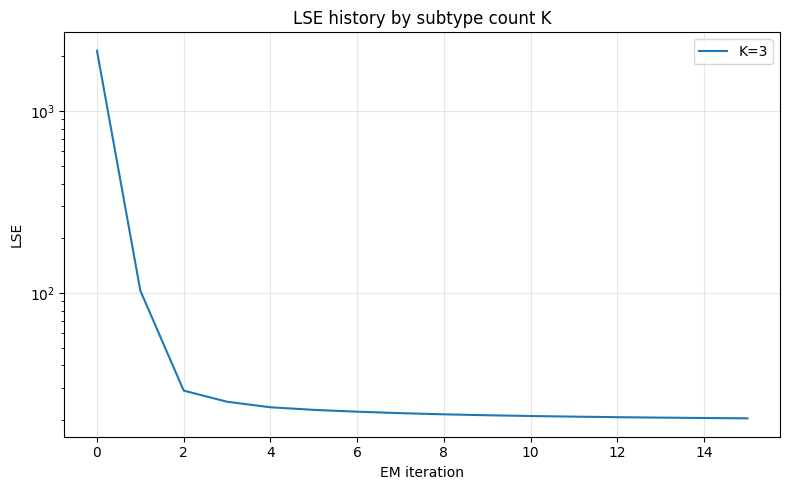

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for K_val in candidate_n_subtypes:
    m = best_model_per_K[K_val]
    if hasattr(m, 'lse_history') and m.lse_history is not None and len(m.lse_history) > 0:
        ax.plot(m.lse_history, label=f'K={K_val}')
ax.set_xlabel('EM iteration')
ax.set_ylabel('LSE')
ax.set_title('LSE history by subtype count K')
ax.legend()
ax.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

## Evaluate Best Model

Now we'll evaluate the best model found by grid search on the full dataset.


In [11]:
# Get the best model
#best_model = grid.best_estimator_
best_model = best_model_per_K[best_n_subtypes]
# Fit on full dataset with best parameters
best_model.verbose = 1  # Enable verbose output for final fit
best_model.fit(X)

print(f"\nBest model final LSE: {best_model.lse_history[-1]:.6f}")


  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:50<00:00,  3.38s/it]


Best model final LSE: 20.394058



Subtype mapping (fitted -> true): [1 2 0]
  Fitted subtype 0 -> True subtype 1
  Fitted subtype 1 -> True subtype 2
  Fitted subtype 2 -> True subtype 0

Fitted Subtype 0 -> True Subtype 1:
  f_fitted:      [0.317  0.0311 0.019 ]
  f_true:        [0.3 0.  0. ]

Fitted Subtype 1 -> True Subtype 2:
  f_fitted:      [0.013  0.3017 0.0035]
  f_true:        [0.  0.3 0. ]

Fitted Subtype 2 -> True Subtype 0:
  f_fitted:      [0.0073 0.0092 0.2495]
  f_true:        [0.  0.  0.3]

Global scalar_K:
  scalar_K_fitted: 0.155199
  scalar_K_true (mean): 0.200000
  scalar_K_true (per subtype): [0.2, 0.2, 0.2]

Global s:
  s_fitted:      [0.9908 0.9581 0.9775]
  s_true:        [1. 1. 1.]

Initial kappa: [0.3422 0.7673 0.5203]
True global kappa: [0.7256 0.     0.6498]
Fit global kappa (final_kappa): [0.6515 0.     0.6029]


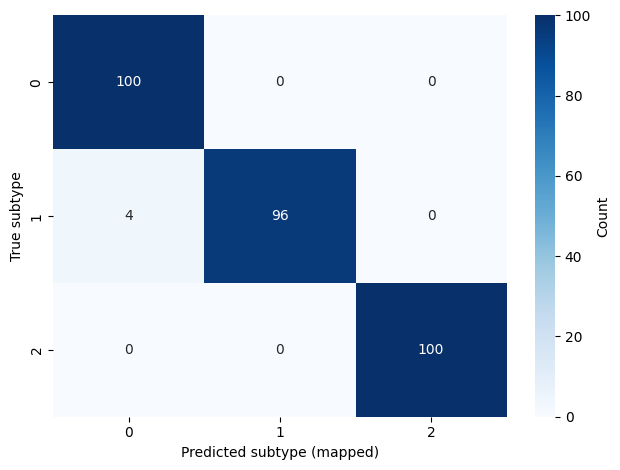

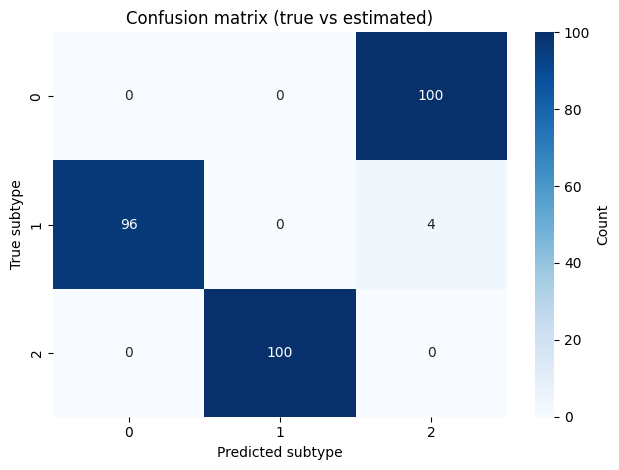


Adjusted Rand Index: 0.9605


In [12]:
import seaborn as sns

# Compute subtype mapping
best_model.compute_subtype_mapping(f_list, verbose=True)
subtype_mapping = best_model.subtype_mapping

# Print parameter comparison
print_parameter_comparison(
    fitted_f_list=best_model.cluster_f,
    fitted_scalar_K=best_model.final_scalar_K,
    fitted_s=best_model.final_s,
    true_f_list=f_list,
    true_scalar_K_list=scalar_K_list,
    true_s=np.ones(n_biomarkers),
    subtype_mapping=best_model.subtype_mapping,
    n_subtypes=n_subtypes,
)

# Kappa: global, not per-cluster (requires fit() after kappa_history was added)
kh = getattr(best_model, "kappa_history", None)
if kh is not None:
    kappa_init = kh[:, 0]
    kappa_final_col = kh[:, -1]
    print(f"\nInitial kappa: {kappa_init}")
print(f"True global kappa: {true_kappa}")
print(f"Fit global kappa (final_kappa): {best_model.final_kappa}")

# Optional: per-biomarker kappa vs EM step (uncomment to plot)
# fig, ax = plt.subplots(figsize=(8, 4))
# for b in range(kh.shape[0]):
#     ax.plot(kh[b, :], marker="o", ms=3, label=f"b={b}")
# ax.set_xlabel("History index (0 = init, then accepted EM iters)")
# ax.set_ylabel("kappa")
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# Confusion matrix
assignments_true = np.array([p["subtype_true"] for p in X])
mapped_assignments = subtype_mapping[best_model.final_assignments]
cm_best = confusion_matrix(assignments_true, mapped_assignments)

fig, ax = plt.subplots()
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=[0, 1, 2], yticklabels=[0, 1, 2],
            cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted subtype (mapped)")
ax.set_ylabel("True subtype")
plt.tight_layout()
plt.show()

cm_raw = confusion_matrix(assignments_true, best_model.final_assignments)
unique_true = np.unique(assignments_true)
unique_pred = np.unique(best_model.final_assignments)
fig, ax = plt.subplots()
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=unique_pred, yticklabels=unique_true,
            cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted subtype")
ax.set_ylabel("True subtype")
ax.set_title("Confusion matrix (true vs estimated)")
plt.tight_layout()
plt.show()

ari = adjusted_rand_score(assignments_true, mapped_assignments)
print(f"\nAdjusted Rand Index: {ari:.4f}")

In [13]:
# import seaborn as sns

# assignments_true = np.array([p["subtype_true"] for p in X])
# mapped_assignments = subtype_mapping[best_model.final_assignments]
# cm_mapped = confusion_matrix(assignments_true, mapped_assignments)

# fig, ax = plt.subplots(figsize=(3, 2.5))
# sns.heatmap(
#     cm_mapped,
#     annot=True,
#     fmt="d",
#     cmap="Blues",
#     ax=ax,
#     xticklabels=[0, 1, 2],
#     yticklabels=[0, 1, 2],
#     cbar_kws={"label": "Count"},
# )
# ax.set_xlabel("Predicted subtype", fontsize=9)
# ax.set_ylabel("True subtype", fontsize=9)
# ax.tick_params(axis="both", labelsize=8)
# plt.tight_layout()
# plt.savefig("confusion_matrix_mapped.pdf", bbox_inches="tight", dpi=300)
# plt.show()

In [14]:
if getattr(best_model, 'assignment_probabilities_', None) is not None:
    import matplotlib.pyplot as plt
    probs = best_model.assignment_probabilities_
    eps = 1e-12
    entropy_per_patient = -np.sum(probs * np.log(probs + eps), axis=1)
    mean_posterior_entropy = np.mean(entropy_per_patient)
    print(f"Mean posterior entropy: {mean_posterior_entropy:.4f}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(np.max(probs, axis=1), bins=20)
    axes[0].set_xlabel('assignment probability (confidence)')
    axes[0].set_ylabel('count')
    axes[0].set_title('max assignment probability per patient')
    axes[1].hist(entropy_per_patient, bins=20)
    axes[1].set_xlabel('posterior entropy')
    axes[1].set_ylabel('ocunt')
    axes[1].set_title('posterior entropy per patient')
    plt.tight_layout()
    plt.show()

## Visualizations


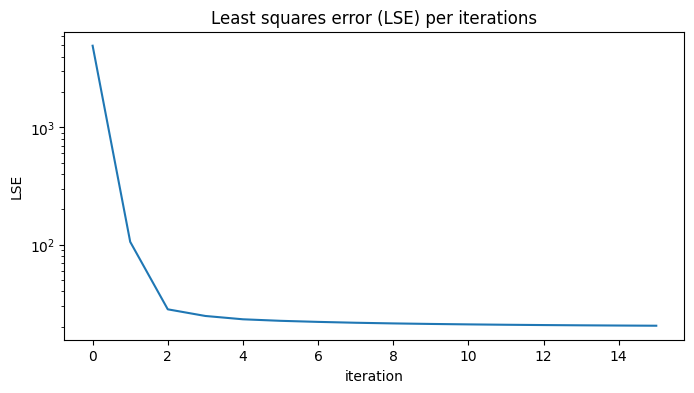

In [15]:
# Plot LSE history
plot_lse(best_model.lse_history)

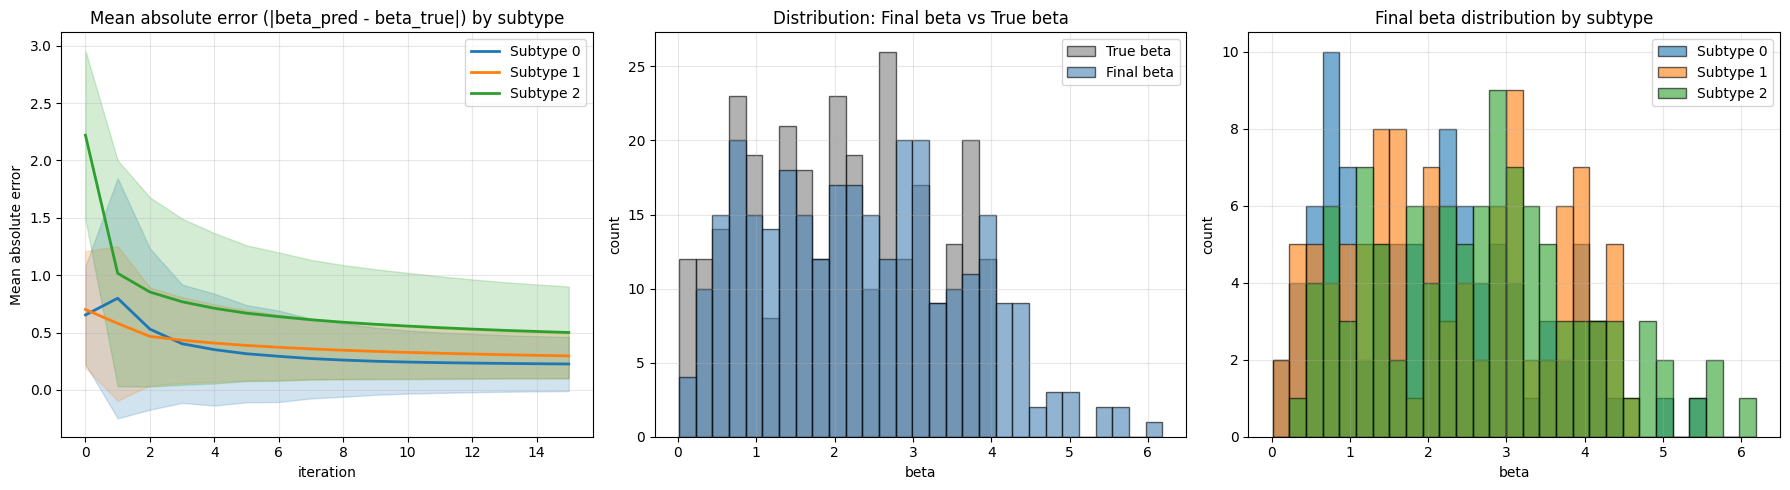

In [16]:
# Plot beta history by subtype
plot_beta_history_by_subtype(
    beta_history=best_model.beta_history,
    assignments=best_model.final_assignments,
    n_subtypes=n_subtypes,
    beta_true=beta_true_array,
    subtype_mapping=subtype_mapping,
)


In [17]:
# Mean absolute error ± std per subtype and overall (final iteration)

beta_pred = best_model.beta_history[:, -1]   # (n_patients,)
beta_true_flat = np.ravel(np.asarray(beta_true_array))  # ensure (n_patients,)
if beta_true_flat.shape[0] != beta_pred.shape[0]:
    raise ValueError("beta_true_array length must match number of patients.")
abs_err = np.abs(beta_pred - beta_true_flat)

assignments = best_model.final_assignments
n_subtypes = int(assignments.max()) + 1

print("Mean |beta_pred - beta_true| ± std by subtype (final iteration):")
print("-" * 55)
all_means, all_stds, counts = [], [], []
for k in range(n_subtypes):
    mask = assignments == k
    if not np.any(mask):
        print(f"  Subtype {k}: (no patients)")
        continue
    ek = abs_err[mask]
    mu, sig = ek.mean(), ek.std(ddof=1)
    nk = ek.size
    all_means.append(mu)
    all_stds.append(sig)
    counts.append(nk)
    print(f"  Subtype {k}: {mu:.4f} ± {sig:.4f}  (n = {nk})")

print("-" * 55)
mu_all = abs_err.mean()
sig_all = abs_err.std(ddof=1)
print(f"  Overall:  {mu_all:.4f} ± {sig_all:.4f}  (n = {abs_err.size})")

Mean |beta_pred - beta_true| ± std by subtype (final iteration):
-------------------------------------------------------
  Subtype 0: 0.2256 ± 0.2369  (n = 96)
  Subtype 1: 0.2963 ± 0.1949  (n = 100)
  Subtype 2: 0.5003 ± 0.4029  (n = 104)
-------------------------------------------------------
  Overall:  0.3444 ± 0.3164  (n = 300)


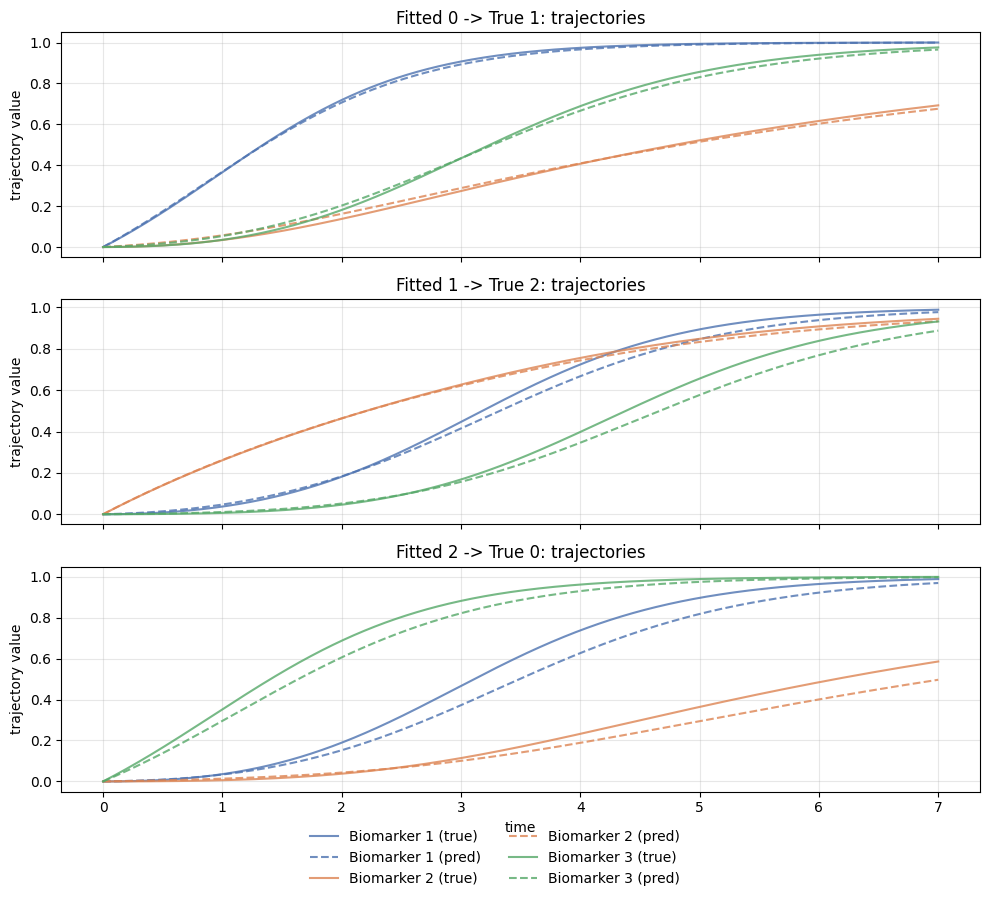

In [18]:
plot_true_vs_predicted_subtype_trajectories(
    n_subtypes=n_subtypes,
    f_true_list=f_list,
    scalar_K_true_list=scalar_K_list,
    f_pred_list=best_model.cluster_f,
    scalar_K_pred_list=[best_model.final_scalar_K] * len(best_model.cluster_f),
    K=K,
    t_span=t_span,
    n_biomarkers=n_biomarkers,
    solve_system_fn=solve_system,
    subtype_mapping=best_model.subtype_mapping,
    kappa_true=true_kappa,
    kappa_pred=best_model.final_kappa,
)

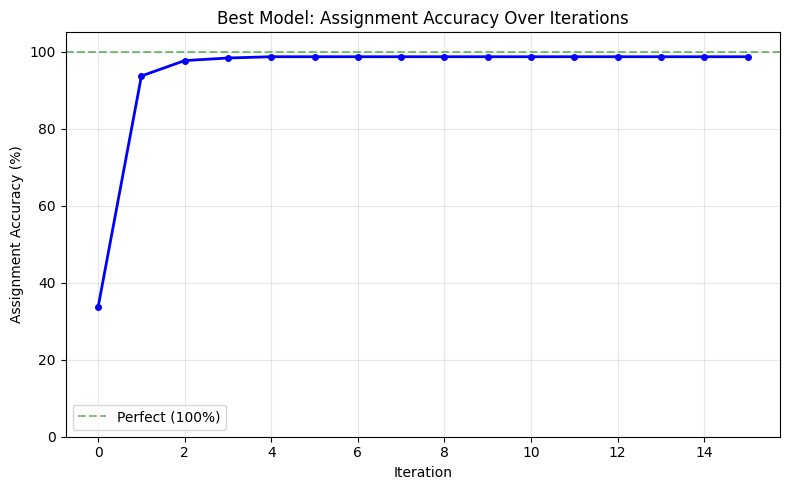

In [19]:
# Plot assignment accuracy over iterations
plot_assignment_accuracy_history(
    assignment_history=best_model.assignment_history,
    true_assignments=assignments_true,
    subtype_mapping=subtype_mapping,
    title="Best Model: Assignment Accuracy Over Iterations",
)


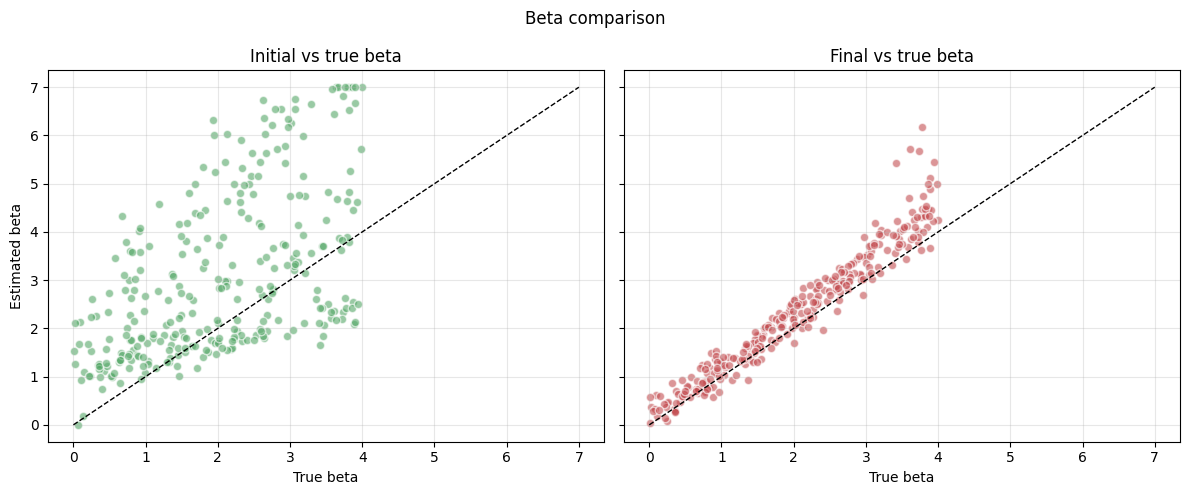

In [20]:
# Plot beta comparison
beta_init_array = np.array([p.get("initial_beta", np.nan) for p in X])
if np.any(np.isnan(beta_init_array)):
    beta_init_array = initial_beta

beta_final_array = best_model.beta_history[:, -1]
plot_beta_comparison(beta_true_array, beta_init_array, beta_final_array)


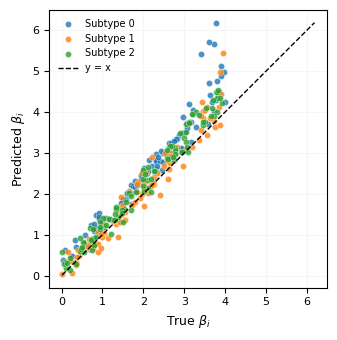

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Use MAPPED subtype for color (so "subtype" = true subtype index after mapping)
assignments = best_model.final_assignments
mapped_assignments = subtype_mapping[assignments]  # same as in confusion matrix

beta_pred = best_model.beta_history[:, -1]
beta_true_flat = np.ravel(np.asarray(beta_true_array))

fig, ax = plt.subplots(figsize=(3.5, 3.5))  # square for side-by-side
colors = plt.get_cmap("tab10").colors
n_subtypes = int(assignments.max()) + 1

for k in range(n_subtypes):
    mask = mapped_assignments == k
    if not np.any(mask):
        continue
    ax.scatter(
        beta_true_flat[mask],
        beta_pred[mask],
        c=[colors[k % len(colors)]],
        label=f"Subtype {k}",
        s=20,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.3,
    )

# Diagonal (perfect prediction)
lims = [
    min(beta_true_flat.min(), beta_pred.min()),
    max(beta_true_flat.max(), beta_pred.max()),
]
ax.plot(lims, lims, "k--", linewidth=1, label="y = x")

ax.set_xlabel(r"True $\beta_i$", fontsize=9)
ax.set_ylabel(r"Predicted $\beta_i$", fontsize=9)
ax.tick_params(axis="both", labelsize=8)
ax.set_aspect("equal")
ax.legend(fontsize=7, frameon=False)
ax.grid(True, alpha=0.1)
plt.tight_layout()
#plt.savefig("beta_true_vs_pred.pdf", bbox_inches="tight", dpi=300)
plt.show()